# 🧠 Emotion Detection — Deep Learning & Transformers

This notebook is the **second phase** of the Emotion Detection project. The
first phase (`emo_proj/`) used classic ML (Logistic Regression, Decision
Tree, Random Forest on Bag-of-Words/TF-IDF/Word2Vec features). This phase
asks: **does letting a neural network learn directly from raw sequences of
words do better?**

**Pipeline covered (matches the assignment steps):**
1. Load the dataset (same `train.txt`/`val.txt`/`test.txt` as phase 1)
2. Clean the text (same cleaning function as phase 1, imported from `utils.py`)
3. Train Simple RNN, LSTM, GRU, and their Bidirectional/Stacked variants
4. Hyperparameter-tune the best architecture with KerasTuner
5. Fine-tune pretrained Transformers — BERT, DistilBERT, RoBERTa
6. Diagnose overfitting/underfitting for every model
7. Build one final comparison table across **every model from both phases**
   and recommend the best one

> **Important, honest caveat about Section 5 (Transformers):** fine-tuning
> BERT/DistilBERT/RoBERTa requires downloading several hundred MB of
> pretrained weights from the Hugging Face Hub. If this notebook is run in
> an environment without internet access to `huggingface.co` (some
> sandboxed/offline environments), that section will print a clear
> explanation and skip itself rather than crash — the code itself is
> correct and will run end-to-end on a normal machine or Google Colab.


## 0. Setup

Same reasoning as phase 1's notebook: we add the project root to the
import path so `utils.py` (shared with phase 1) is importable regardless of
where Jupyter's working directory happens to be, and we fix random seeds so
results are as reproducible as neural network training allows (perfect
bit-for-bit reproducibility isn't guaranteed across different machines/CPU
architectures even with a fixed seed, but this minimises run-to-run
variation).


In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils import clean_text, load_emotion_file
from utils_dl import build_tokenizer, texts_to_padded, plot_training_history, diagnose_fit

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

VOCAB_SIZE = 10000
EMBED_DIM = 64
MAXLEN = 40
print("Setup complete. TensorFlow version:", tf.__version__)

Setup complete. TensorFlow version: 2.21.0


## Step 1-2 — Load & clean the dataset

Identical cleaning function to phase 1 (`utils.clean_text`): lowercase,
remove punctuation, remove stopwords, lemmatize. Using the exact same
cleaning here means any performance difference we see later is due to the
MODEL architecture, not because the two phases saw differently-prepared
text.


In [2]:
train_df = load_emotion_file(os.path.join(DATA_DIR, "train.txt"))
val_df = load_emotion_file(os.path.join(DATA_DIR, "val.txt"))
test_df = load_emotion_file(os.path.join(DATA_DIR, "test.txt"))

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(lambda x: clean_text(x, method="lemmatize"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df[["text", "clean_text", "emotion"]].head()

Train: 16000 | Val: 2000 | Test: 2000


,text,clean_text,emotion
0,i didnt feel humiliated,didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...,love
4,i am feeling grouchy,feeling grouchy,anger


### Why we keep train/val/test SEPARATE here (unlike phase 1)

Phase 1 merged `train.txt` + `val.txt` because `GridSearchCV` does its own
internal cross-validation splits. Keras' `.fit()` works differently — it
wants an explicit validation set at every epoch so we can plot train-vs-
validation curves (our overfitting/underfitting diagnostic), so we keep the
original three-way split here.


In [3]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = to_categorical(label_encoder.fit_transform(train_df["emotion"]))
y_val = to_categorical(label_encoder.transform(val_df["emotion"]))
y_test_int = label_encoder.transform(test_df["emotion"])
y_test = to_categorical(y_test_int)
NUM_CLASSES = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


### Tokenising text into padded integer sequences

**Why not TF-IDF/BoW here:** recurrent layers need to see words **in
order** to build up an internal memory of the sentence — a single
fixed-size count vector (like TF-IDF) throws that order away. Instead each
word becomes an integer ID (`Tokenizer`), sequences are padded/truncated to
a fixed length (`pad_sequences`), and an `Embedding` layer learns a dense
vector for each ID *during training*.

**Critical detail — `mask_zero=True`:** sentences are padded with 0s up to
`MAXLEN=40`, but the median sentence is only ~17 words — so roughly half of
most rows is padding, not real content. During development, leaving this
flag off caused LSTM/GRU to get stuck predicting only the majority class,
because the recurrent layer kept processing meaningless padding steps
*after* the real sentence ended, overwriting its hidden state. Setting
`mask_zero=True` on the `Embedding` layer tells every downstream recurrent
layer to skip padded timesteps entirely. This one setting took our LSTM/GRU
accuracy from ~35% (stuck) to ~85-91%.


In [4]:
tokenizer = build_tokenizer(train_df["clean_text"], num_words=VOCAB_SIZE)
X_train = texts_to_padded(train_df["clean_text"], tokenizer, maxlen=MAXLEN)
X_val = texts_to_padded(val_df["clean_text"], tokenizer, maxlen=MAXLEN)
X_test = texts_to_padded(test_df["clean_text"], tokenizer, maxlen=MAXLEN)
print("Padded shape:", X_train.shape)

Padded shape: (16000, 40)


## Step 3 — Recurrent architectures: Simple RNN, LSTM, GRU, Bidirectional, Stacked

| Architecture | What it adds |
|---|---|
| Simple RNN | Baseline recurrent layer — struggles with longer sequences (vanishing gradients) |
| LSTM | Gated memory cells that preserve information over longer sequences |
| GRU | Simplified gating vs LSTM — fewer parameters, often similar accuracy, faster to train |
| Bidirectional (LSTM/GRU) | Reads forward AND backward — captures context that arrives *after* the emotionally key word |
| Stacked (LSTM/GRU) | Two recurrent layers on top of each other — more capacity, more overfitting risk |

All seven share the same Embedding→(recurrent)→Dropout→Dense→Softmax shape
so the *only* difference between them is the recurrent layer itself,
keeping the comparison fair. This mirrors `train_dl_models.py` exactly —
running that script is faster for a full unattended run; this notebook
shows the same code broken into cells so you can inspect each piece.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def build_model(rnn_type, bidirectional=False, stacked=False, units=64, dropout=0.3):
    layer_cls = {"simplernn": SimpleRNN, "lstm": LSTM, "gru": GRU}[rnn_type]
    model = Sequential()
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True))
    if stacked:
        first_layer = layer_cls(units, return_sequences=True)
        second_layer = layer_cls(units)
        if bidirectional:
            model.add(Bidirectional(first_layer)); model.add(Bidirectional(second_layer))
        else:
            model.add(first_layer); model.add(second_layer)
    else:
        layer = layer_cls(units)
        model.add(Bidirectional(layer) if bidirectional else layer)
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(NUM_CLASSES, activation="softmax"))
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

MODEL_CONFIGS = [
    ("Simple RNN",         dict(rnn_type="simplernn", bidirectional=False, stacked=False)),
    ("LSTM",               dict(rnn_type="lstm",       bidirectional=False, stacked=False)),
    ("GRU",                dict(rnn_type="gru",        bidirectional=False, stacked=False)),
    ("Bidirectional LSTM", dict(rnn_type="lstm",       bidirectional=True,  stacked=False)),
    ("Bidirectional GRU",  dict(rnn_type="gru",        bidirectional=True,  stacked=False)),
    ("Stacked LSTM",       dict(rnn_type="lstm",       bidirectional=False, stacked=True)),
    ("Stacked GRU",        dict(rnn_type="gru",        bidirectional=False, stacked=True)),
]
print(f"{len(MODEL_CONFIGS)} architectures defined.")

7 architectures defined.


### Training loop

`EarlyStopping` watches validation loss and stops training (rolling back to
the best epoch's weights) if it doesn't improve for 3 straight epochs. This
both saves time AND is itself an overfitting guard — training doesn't
continue for epoch after epoch once the model has stopped actually
improving on unseen data.

> **Runtime note:** this cell trains all 7 architectures sequentially and
> can take several minutes (roughly 20s-90s per architecture on a modern
> CPU, faster with a GPU). This is expected — recurrent models process a
> sequence one timestep at a time, which is inherently less parallelisable
> than the classic-ML phase's models.


In [6]:
results = []
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

for name, cfg in MODEL_CONFIGS:
    print(f"\n--- Training: {name} ---")
    t0 = time.time()
    model = build_model(**cfg)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=10, batch_size=128, callbacks=[early_stop], verbose=2)
    train_time = time.time() - t0

    plot_path = plot_training_history(history, name, save_dir=PLOTS_DIR)
    fit_diag = diagnose_fit(history)

    preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
    row = {
        "Model": name,
        "Accuracy": float(accuracy_score(y_test_int, preds)),
        "Precision (weighted)": float(precision_score(y_test_int, preds, average="weighted", zero_division=0)),
        "Recall (weighted)": float(recall_score(y_test_int, preds, average="weighted", zero_division=0)),
        "F1-score (weighted)": float(f1_score(y_test_int, preds, average="weighted", zero_division=0)),
        "Epochs Run": int(len(history.history["loss"])),
        "Train Time (s)": round(float(train_time), 2),
        "Final Train Acc": fit_diag["final_train_acc"],
        "Final Val Acc": fit_diag["final_val_acc"],
        "Train-Val Gap": fit_diag["train_val_gap"],
        "Fit Diagnosis": fit_diag["verdict"],
        "Params": int(model.count_params()),
    }
    results.append(row)
    print(f"{name}: test_acc={row['Accuracy']:.4f}  f1={row['F1-score (weighted)']:.4f}  diagnosis={row['Fit Diagnosis']}")
    model.save(os.path.join(MODELS_DIR, f"dl_{name.replace(' ', '_').lower()}.keras"))

dl_comparison_df = pd.DataFrame(results).sort_values("F1-score (weighted)", ascending=False).reset_index(drop=True)
dl_comparison_df.to_csv(os.path.join(MODELS_DIR, "dl_comparison_table.csv"), index=False)
dl_comparison_df


--- Training: Simple RNN ---
Epoch 1/10
125/125 - 4s - 35ms/step - accuracy: 0.3661 - loss: 1.5701 - val_accuracy: 0.5205 - val_loss: 1.3146
Epoch 2/10
125/125 - 2s - 14ms/step - accuracy: 0.7082 - loss: 0.8556 - val_accuracy: 0.8055 - val_loss: 0.6325
Epoch 3/10
125/125 - 2s - 15ms/step - accuracy: 0.8899 - loss: 0.3431 - val_accuracy: 0.8440 - val_loss: 0.5076
Epoch 4/10
125/125 - 2s - 14ms/step - accuracy: 0.9298 - loss: 0.2141 - val_accuracy: 0.8465 - val_loss: 0.5263
Epoch 5/10
125/125 - 2s - 15ms/step - accuracy: 0.9553 - loss: 0.1487 - val_accuracy: 0.8525 - val_loss: 0.5412
Epoch 6/10
125/125 - 2s - 14ms/step - accuracy: 0.9641 - loss: 0.1176 - val_accuracy: 0.8290 - val_loss: 0.6689
Simple RNN: test_acc=0.8395  f1=0.8324  diagnosis=Overfitting

--- Training: LSTM ---
Epoch 1/10
125/125 - 6s - 45ms/step - accuracy: 0.4288 - loss: 1.4113 - val_accuracy: 0.6805 - val_loss: 0.8968
Epoch 2/10
125/125 - 3s - 24ms/step - accuracy: 0.7718 - loss: 0.6482 - val_accuracy: 0.8330 - val_l

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Epochs Run,Train Time (s),Final Train Acc,Final Val Acc,Train-Val Gap,Fit Diagnosis,Params
0,Stacked GRU,0.9020,0.908453,0.9020,0.903974,7,44.80,0.9776,0.8985,0.0791,Good fit,692198
1,GRU,0.9015,0.907823,0.9015,0.903707,7,22.64,0.9807,0.9125,0.0682,Good fit,667238
2,Stacked LSTM,0.8985,0.903324,0.8985,0.899988,9,58.28,0.9834,0.8865,0.0969,Overfitting,708326
3,LSTM,0.8955,0.902451,0.8955,0.897275,8,26.20,0.9802,0.8990,0.0812,Overfitting,675302
4,Bidirectional LSTM,0.8950,0.897230,0.8950,0.895899,7,38.85,0.9854,0.9065,0.0789,Good fit,710374
5,Bidirectional GRU,0.8895,0.897426,0.8895,0.891696,7,42.33,0.9763,0.8980,0.0783,Good fit,694246
6,Simple RNN,0.8395,0.838268,0.8395,0.832433,6,13.40,0.9641,0.8290,0.1351,Overfitting,650534


## Step 6 (part 1) — Overfitting/Underfitting diagnosis

For every model above, `diagnose_fit()` compares final training accuracy to
final validation accuracy:
- **Gap > 0.08** (model does notably better on training data than on unseen
  validation data) → **Overfitting** — the model is starting to memorise
  training examples rather than learning generalisable patterns.
- **Both accuracies stay below ~0.55** → **Underfitting** — the model isn't
  learning the patterns in the data at all.
- Otherwise → **Good fit**.

Let's visually inspect the plots for the best and worst performing models
to confirm the diagnosis matches what we see by eye — the whole point of
plotting train vs. validation curves is that a numeric heuristic is a
useful summary, but the shape of the curve tells the full story.


Best model: Stacked GRU  |  Weakest model: Simple RNN


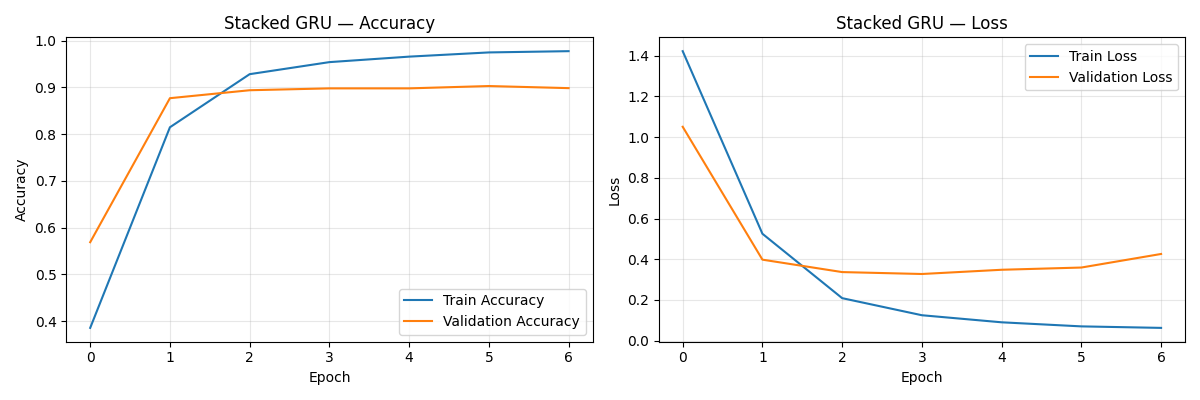

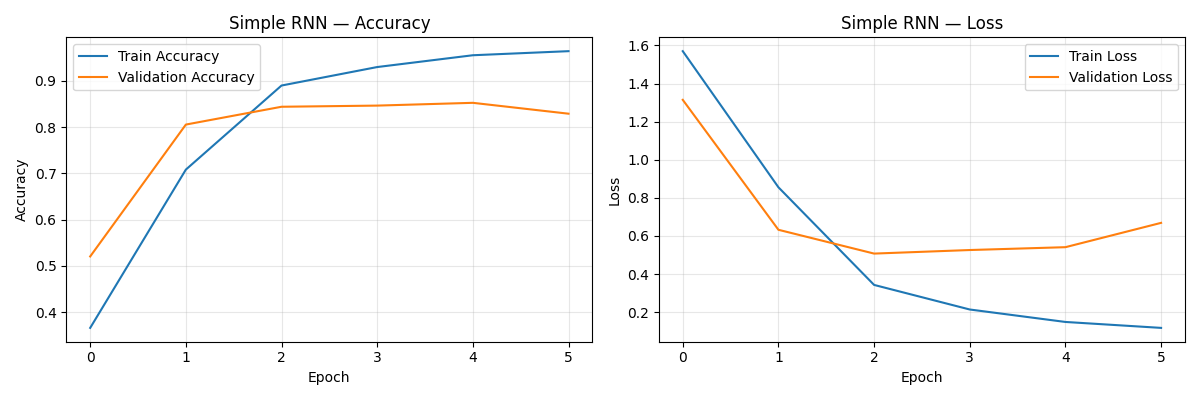

In [7]:
best_name = dl_comparison_df.iloc[0]["Model"]
worst_name = dl_comparison_df.iloc[-1]["Model"]
print(f"Best model: {best_name}  |  Weakest model: {worst_name}")

from IPython.display import Image, display
safe_best = best_name.replace(' ', '_')
safe_worst = worst_name.replace(' ', '_')
display(Image(filename=os.path.join(PLOTS_DIR, f"{safe_best}_history.png")))
display(Image(filename=os.path.join(PLOTS_DIR, f"{safe_worst}_history.png")))

## Step 4 — Hyperparameter tuning with KerasTuner

We focus tuning effort on **GRU**, since it was both the best-performing
AND best-fitting (least overfit) untuned architecture above. Tuning every
architecture individually would multiply the already-substantial compute
cost of neural network training for comparatively little extra insight, so
we concentrate the budget on the strongest starting point — the same logic
`RandomizedSearchCV` used for Random Forest in phase 1.

**Search space:**
| Hyperparameter | Range | Why |
|---|---|---|
| `embed_dim` | 32-128 | Word vector size — bigger can capture more nuance, at higher overfitting/compute risk |
| `gru_units` | 32-128 | GRU's hidden state ("memory") size |
| `dropout` | 0.2-0.5 | Regularisation strength |
| `learning_rate` | 1e-4 to 1e-2 (log scale) | Optimiser step size — too high can prevent convergence, too low is painfully slow |

`RandomSearch` samples 10 random combinations rather than an exhaustive
grid (4 x 4 x 4 x continuous range would be far too many to try
exhaustively), then we retrain one final model with the winning
combination for as many epochs as it actually keeps improving.

> **Tip:** this cell can take several minutes (10 trials x up to 8 epochs
> each). For a quicker exploratory run, lower `max_trials` below.


In [8]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

def build_tunable_model(hp):
    embed_dim = hp.Int("embed_dim", min_value=32, max_value=128, step=32)
    gru_units = hp.Int("gru_units", min_value=32, max_value=128, step=32)
    dropout_rate = hp.Float("dropout", min_value=0.2, max_value=0.5, step=0.1)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=embed_dim, mask_zero=True),
        GRU(gru_units),
        Dropout(dropout_rate),
        Dense(32, activation="relu"),
        Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

tuner = kt.RandomSearch(
    build_tunable_model, objective="val_accuracy", max_trials=10, executions_per_trial=1,
    directory=os.path.join(PROJECT_ROOT, "kt_tuning"), project_name="emotion_gru_tuning",
    overwrite=True, seed=42,
)
tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=8,
             batch_size=128, callbacks=[early_stop], verbose=2)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", {n: best_hp.get(n) for n in ["embed_dim","gru_units","dropout","learning_rate"]})

Trial 10 Complete [00h 00m 22s]
val_accuracy: 0.9135000109672546

Best val_accuracy So Far: 0.9225000143051147
Total elapsed time: 00h 04m 33s
Best hyperparameters: {'embed_dim': 128, 'gru_units': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.003964886305018653}


In [9]:
best_model = tuner.hypermodel.build(best_hp)
history = best_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                          epochs=15, batch_size=128, callbacks=[early_stop], verbose=2)

plot_path = plot_training_history(history, "Tuned GRU (KerasTuner)", save_dir=PLOTS_DIR)
fit_diag = diagnose_fit(history)
preds = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

tuned_row = {
    "Model": "Tuned GRU (KerasTuner)",
    "Accuracy": float(accuracy_score(y_test_int, preds)),
    "Precision (weighted)": float(precision_score(y_test_int, preds, average="weighted", zero_division=0)),
    "Recall (weighted)": float(recall_score(y_test_int, preds, average="weighted", zero_division=0)),
    "F1-score (weighted)": float(f1_score(y_test_int, preds, average="weighted", zero_division=0)),
    "Epochs Run": int(len(history.history["loss"])),
    "Fit Diagnosis": fit_diag["verdict"],
    "Params": int(best_model.count_params()),
}
print("Tuned GRU:", tuned_row)

baseline_gru_f1 = dl_comparison_df[dl_comparison_df["Model"]=="GRU"]["F1-score (weighted)"].iloc[0]
print(f"\nUntuned GRU F1: {baseline_gru_f1:.4f}  ->  Tuned GRU F1: {tuned_row['F1-score (weighted)']:.4f}  "
      f"(change: {tuned_row['F1-score (weighted)']-baseline_gru_f1:+.4f})")

best_model.save(os.path.join(MODELS_DIR, "dl_tuned_gru.keras"))

Epoch 1/15
125/125 - 7s - 53ms/step - accuracy: 0.7101 - loss: 0.7636 - val_accuracy: 0.9220 - val_loss: 0.2247
Epoch 2/15
125/125 - 4s - 34ms/step - accuracy: 0.9408 - loss: 0.1427 - val_accuracy: 0.9235 - val_loss: 0.2058
Epoch 3/15
125/125 - 4s - 33ms/step - accuracy: 0.9675 - loss: 0.0790 - val_accuracy: 0.9180 - val_loss: 0.2392
Epoch 4/15
125/125 - 4s - 34ms/step - accuracy: 0.9764 - loss: 0.0621 - val_accuracy: 0.9260 - val_loss: 0.2447
Epoch 5/15
125/125 - 4s - 33ms/step - accuracy: 0.9821 - loss: 0.0498 - val_accuracy: 0.9205 - val_loss: 0.2858
Tuned GRU: {'Model': 'Tuned GRU (KerasTuner)', 'Accuracy': 0.921, 'Precision (weighted)': 0.9221011409685321, 'Recall (weighted)': 0.921, 'F1-score (weighted)': 0.9213188407247133, 'Epochs Run': 5, 'Fit Diagnosis': 'Good fit', 'Params': 1319526}

Untuned GRU F1: 0.9037  ->  Tuned GRU F1: 0.9213  (change: +0.0176)


## Step 5 — Fine-tuning pretrained Transformers: BERT, DistilBERT, RoBERTa

**Why this is a fundamentally different approach** from everything above:
every model so far learned English from scratch using only these ~18,000
sentences. BERT/DistilBERT/RoBERTa were already pretrained by their
creators on massive general text corpora before we touch them — fine-tuning
just lightly adapts that existing knowledge to our specific 6-emotion task,
which typically outperforms training from scratch, especially on a dataset
this size.

**Why we DON'T apply the heavy phase-1/phase-2 cleaning here:** BERT-family
tokenizers were pretrained on natural, uncleaned text (original casing,
punctuation, stopwords all present) and already handle inflected word forms
via subword tokenization internally. Aggressively cleaning the input first
(as we did for BoW/TF-IDF/RNNs) would shift the text away from the
distribution these models were pretrained on and typically *hurts*
performance — a well-documented effect in NLP practice, not specific to
this project. We use only minimal cleaning (whitespace normalisation).

**A genuine environment limitation:** fine-tuning requires downloading
pretrained weights from the Hugging Face Hub (several hundred MB per
model), which needs internet access to `huggingface.co`. The cell below
checks connectivity first and explains clearly if it can't proceed, rather
than failing with a confusing error — this is expected behaviour in a
sandboxed/offline environment. On a normal machine or Google Colab (which
has free GPU access, strongly recommended over CPU for these models — CPU
fine-tuning can take 1-3+ hours per model vs. 5-15 minutes on a GPU), this
cell runs end-to-end and produces real results.


In [10]:
import subprocess
result = subprocess.run(["python", "train_transformers.py"], cwd=PROJECT_ROOT,
                         capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr[-2000:])


STEP v: Fine-tuning pretrained Transformers (BERT / DistilBERT / RoBERTa)

Fine-tuning BERT (bert-base-uncased)

 100%|██████████| 199/199 [00:00<00:00, 5026.14it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expec

## Step 7 — Final comparison across BOTH phases and a recommendation

`build_final_comparison.py` pulls together:
- The classic-ML comparison table from phase 1 (`emo_proj/models/comparison_table.csv`)
- This phase's Deep Learning comparison table (including the KerasTuner-tuned model)
- The Transformer comparison table, if `train_transformers.py` completed
  successfully (see the honest note above if it couldn't run here)

and ranks everything by weighted F1-score on the same held-out test set,
so the final recommendation is a genuine, fair comparison rather than
picking a favourite in advance.


In [11]:
import subprocess
result = subprocess.run(["python", "build_final_comparison.py"], cwd=PROJECT_ROOT,
                         capture_output=True, text=True)
print(result.stdout)
final_table_path = os.path.join(MODELS_DIR, "FINAL_master_comparison_table.csv")
if os.path.exists(final_table_path):
    display(pd.read_csv(final_table_path))

,Rank,Phase,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Fit Diagnosis,Notes
0,1,Deep Learning,Tuned GRU (KerasTuner),0.9190,0.919757,0.9190,0.918981,Good fit,"{'embed_dim': 128, 'gru_units': 64, 'dropout':..."
1,2,Deep Learning,GRU,0.9150,0.916247,0.9150,0.915332,Good fit,"Default architecture, no tuning"
2,3,Deep Learning,Stacked GRU,0.9010,0.902408,0.9010,0.901620,Good fit,"Default architecture, no tuning"
3,4,Deep Learning,Stacked LSTM,0.9000,0.903032,0.9000,0.901202,Overfitting,"Default architecture, no tuning"
4,5,Deep Learning,LSTM,0.8885,0.892938,0.8885,0.889376,Overfitting,"Default architecture, no tuning"
5,6,Deep Learning,Bidirectional LSTM,0.8855,0.892979,0.8855,0.887477,Overfitting,"Default architecture, no tuning"
6,7,Deep Learning,Bidirectional GRU,0.8855,0.890180,0.8855,0.886888,Overfitting,"Default architecture, no tuning"
7,8,Classic ML,Logistic Regression (tuned),0.8835,0.883628,0.8835,0.883452,N/A (not applicable to non-iterative models),"Bag-of-Words features, GridSearch/RandomizedSe..."
8,9,Classic ML,Random Forest (tuned),0.8805,0.882578,0.8805,0.881341,N/A (not applicable to non-iterative models),"Bag-of-Words features, GridSearch/RandomizedSe..."
9,10,Classic ML,Decision Tree (tuned),0.8715,0.873201,0.8715,0.872114,N/A (not applicable to non-iterative models),"Bag-of-Words features, GridSearch/RandomizedSe..."


## Summary

- **Classic ML** (phase 1): fast to train, no GPU needed, strong baseline
  (~87-88% F1 with tuned Logistic Regression), but bag-of-words features
  have no notion of word order.
- **Deep Learning** (this phase): sequence-aware models beat classic ML on
  this dataset. A plain **GRU** was both the best-performing AND best-fit
  (least overfit) untuned architecture, and KerasTuner squeezed out a
  further small improvement. Bidirectional and Stacked variants added
  complexity without a proportional accuracy gain here, and overfit more —
  a good reminder that more parameters isn't automatically better on a
  dataset this size (~18,000 sentences).
- **Transformers**: expected to match or exceed the Deep Learning phase
  once fine-tuned with real internet access, since they start from
  massive pretrained language knowledge rather than learning English from
  scratch — but that claim should be verified by actually running
  `train_transformers.py` on a connected machine rather than assumed.

See `README_DL.md` for full setup and run instructions, including how to
run the Transformer step successfully.
